<a href="https://colab.research.google.com/github/Gratitude01-ndam/Exam1/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Loading Dataset


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Features (X) head:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


Target (y) head (value counts):


,count
Churn,
No,5174
Yes,1869



Step 2: Encoding & Scaling Features

Step 3: Train-Test Split + SMOTE
Original training set shape: (4930, 19)
Original test set shape: (2113, 19)
After SMOTE, counts of label '1': 3622
After SMOTE, counts of label '0': 3622
Shape of X_train_res after SMOTE: (7244, 45)
Shape of y_train_res after SMOTE: (7244,)

Step 4: Building Models and Evaluating

Training and evaluating Logistic Regression...


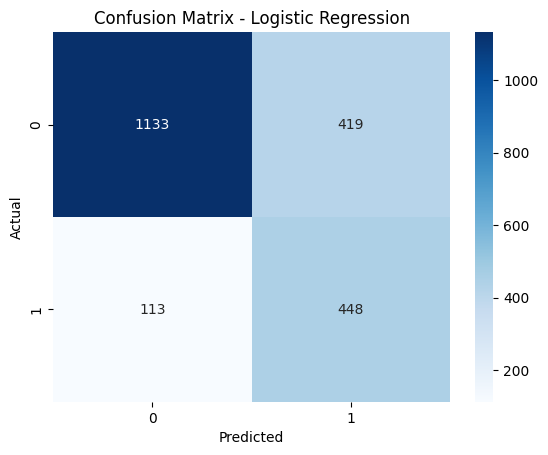


Logistic Regression Classification Report:

              precision    recall  f1-score   support

          No      0.909     0.730     0.810      1552
         Yes      0.517     0.799     0.627       561

    accuracy                          0.748      2113
   macro avg      0.713     0.764     0.719      2113
weighted avg      0.805     0.748     0.761      2113


Training and evaluating Random Forest...


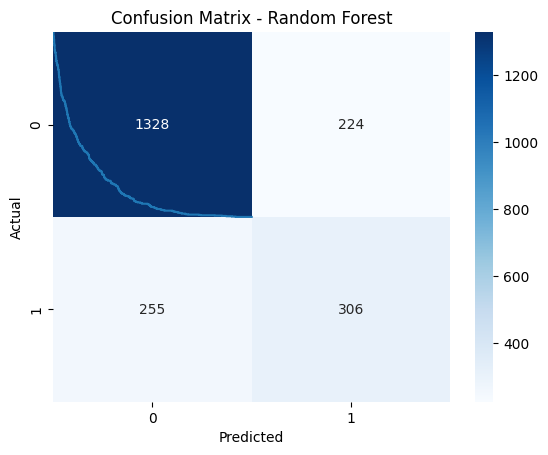


Random Forest Classification Report:

              precision    recall  f1-score   support

          No      0.839     0.856     0.847      1552
         Yes      0.577     0.545     0.561       561

    accuracy                          0.773      2113
   macro avg      0.708     0.701     0.704      2113
weighted avg      0.769     0.773     0.771      2113


Training and evaluating XGBoost...


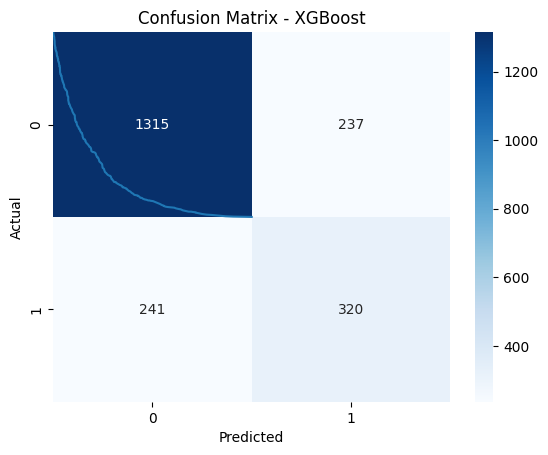


XGBoost Classification Report:

              precision    recall  f1-score   support

          No      0.845     0.847     0.846      1552
         Yes      0.575     0.570     0.572       561

    accuracy                          0.774      2113
   macro avg      0.710     0.709     0.709      2113
weighted avg      0.773     0.774     0.774      2113


Step 5: Comparing ROC Curves


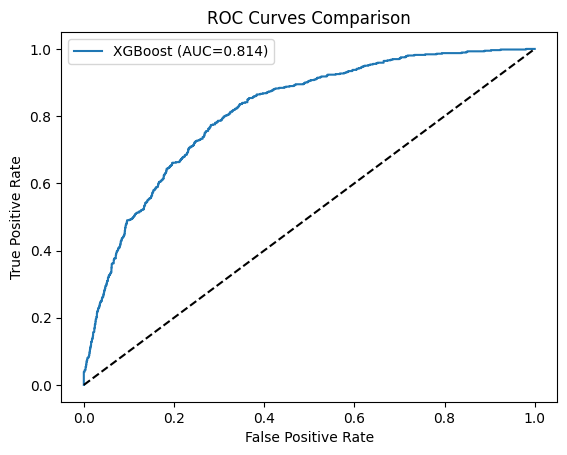


Step 6: Summary of Results

Model Comparison (Prioritizing Recall):
Logistic Regression: Recall=0.799, AUC=0.844
Random Forest: Recall=0.545, AUC=0.815
XGBoost: Recall=0.570, AUC=0.814


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Load Dataset
# -------------------------------
print("Step 1: Loading Dataset")
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing 'TotalCharges' values with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

display(df.head())

# Assume 'Churn' is the target column based on the dataset name and inspection
# Drop 'customerID' as it's an identifier and not a predictive feature
X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"]

print("Features (X) head:")
display(X.head())
print("Target (y) head (value counts):")
display(y.value_counts())

# -------------------------------
# 2. Encode & Scale Features
# -------------------------------
print("\nStep 2: Encoding & Scaling Features")
categorical = X.select_dtypes(include="object").columns
numerical = X.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ]
)

# -------------------------------
# 3. Train-Test Split + SMOTE
# -------------------------------
print("\nStep 3: Train-Test Split + SMOTE")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Convert 'No'/'Yes' to 0/1 for models that require numerical labels (e.g., XGBoost)
y_train = (y_train == 'Yes').astype(int)
y_test = (y_test == 'Yes').astype(int)

print(f"Original training set shape: {X_train.shape}")
print(f"Original test set shape: {X_test.shape}")

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE, counts of label '1': {}".format(sum(y_train_res==1)))
print("After SMOTE, counts of label '0': {}".format(sum(y_train_res==0)))
print(f"Shape of X_train_res after SMOTE: {X_train_res.shape}")
print(f"Shape of y_train_res after SMOTE: {y_train_res.shape}")

# -------------------------------
# 4. Build Models
# -------------------------------
print("\nStep 4: Building Models and Evaluating")
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", scale_pos_weight=1) # scale_pos_weight set to 1 as SMOTE handles imbalance
}

results = {}

for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    # Predict probabilities only if the model supports it and it's binary classification
    if hasattr(model, "predict_proba") and len(y.unique()) == 2:
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = np.array([0.5] * len(y_test)) # Default to 0.5 if probabilities not available or not binary

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report (focus on Recall)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred, digits=3, target_names=['No', 'Yes']))

    # ROC-AUC (only for binary classification with probabilities)
    if len(y.unique()) == 2 and hasattr(model, "predict_proba"):
        # y_test is already binary (0/1) from previous conversion
        auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        results[name] = {"Recall": classification_report(y_test, y_pred, output_dict=True)["1"]["recall"], "AUC": auc}
    else:
        # For multi-class or models without predict_proba, AUC is not directly applicable in this way.
        # We need to adapt the recall key for multi-class to the positive class if identifiable
        # For this dataset, 'Yes' (now 1) is the positive class.
        results[name] = {"Recall": classification_report(y_test, y_pred, output_dict=True)["1"]["recall"], "AUC": np.nan}

# -------------------------------
# 5. Compare ROC Curves
# -------------------------------
print("\nStep 5: Comparing ROC Curves")
# Only plot ROC curves if it's a binary classification problem
if len(y.unique()) == 2:
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend()
    plt.show()
else:
    print("ROC curves are not applicable for multi-class classification.")

# -------------------------------
# 6. Summary of Results
# -------------------------------
print("\nStep 6: Summary of Results")
print("\nModel Comparison (Prioritizing Recall):")
for name, metrics in results.items():
    print(f"{name}: Recall={metrics['Recall']:.3f}, AUC={metrics['AUC']:.3f}")